# Estructuras de Datos y Algoritmos para ML

**Pregunta:** Que necesito saber de estructuras de datos y algoritmos para trabajar en Machine Learning y Data Science?

No necesitas ser experto en programacion competitiva. Necesitas entender:
1. **Complejidad computacional** — por que un modelo tarda lo que tarda
2. **Estructuras de datos** — como se organizan los datos internamente
3. **Vectorizacion** — por que numpy es 100x mas rapido que un loop de Python

---

## 1. Complejidad Computacional: Big-O

Big-O describe como crece el tiempo de ejecucion cuando crece el tamanio de los datos.

| Notacion | Nombre | Ejemplo | 1,000 datos | 1,000,000 datos |
|---|---|---|---|---|
| O(1) | Constante | Acceder a dict[key] | Instantaneo | Instantaneo |
| O(log n) | Logaritmico | Busqueda binaria | 10 ops | 20 ops |
| O(n) | Lineal | Recorrer una lista | 1,000 ops | 1,000,000 ops |
| O(n log n) | Linearitmico | Sorting (merge sort) | 10,000 ops | 20,000,000 ops |
| O(n²) | Cuadratico | Doble loop, distancias | 1,000,000 ops | 10¹² ops (imposible) |
| O(n³) | Cubico | Inv. de matriz, OLS | 10⁹ ops | 10¹⁸ ops (imposible) |

**Por que importa en ML:**
- KNN con n=1M: calcular distancias es O(n) por prediccion — lento
- Inversion de matriz (OLS): O(p³) — por eso gradient descent con p>1000
- Sorting para encontrar medianas: O(n log n)

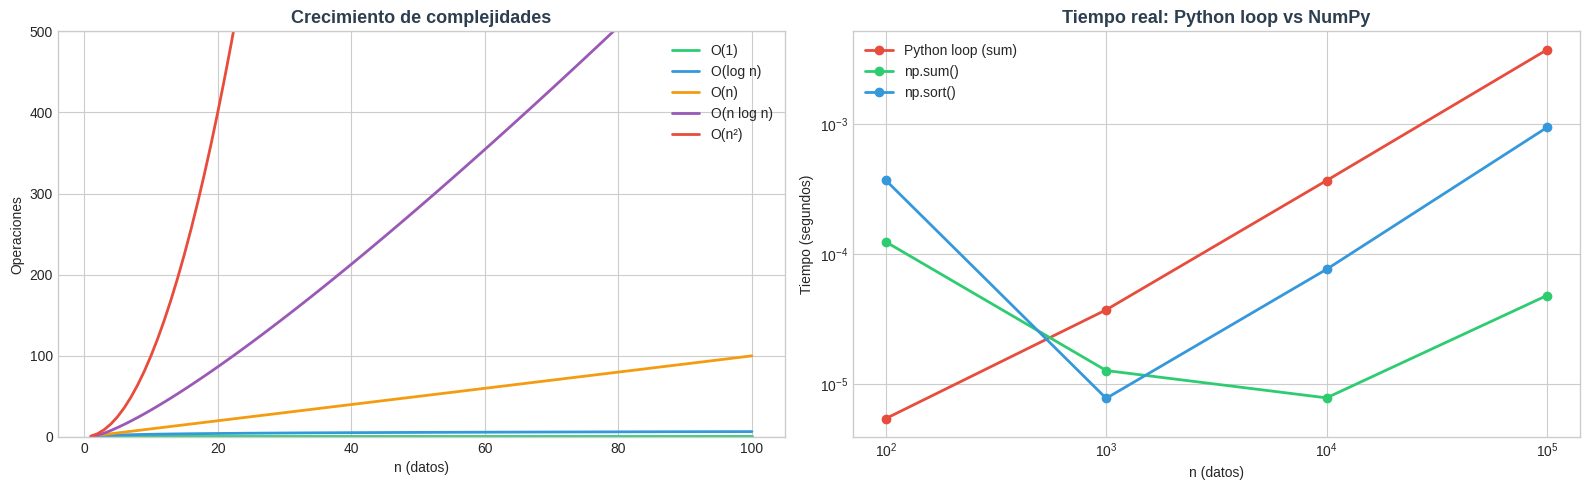

Con n=100,000: Python loop = 3.7ms, NumPy = 0.048ms
NumPy es 77x mas rapido que un loop de Python


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
C_PRIMARY = '#3498db'
C_DANGER = '#e74c3c'
C_SUCCESS = '#2ecc71'
C_DARK = '#2c3e50'
C_ORANGE = '#f39c12'
C_PURPLE = '#9b59b6'

# === Visualizar complejidades ===
n = np.arange(1, 101)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(n, np.ones_like(n), linewidth=2, label='O(1)', color=C_SUCCESS)
ax.plot(n, np.log2(n), linewidth=2, label='O(log n)', color=C_PRIMARY)
ax.plot(n, n, linewidth=2, label='O(n)', color=C_ORANGE)
ax.plot(n, n * np.log2(n), linewidth=2, label='O(n log n)', color=C_PURPLE)
ax.plot(n, n**2, linewidth=2, label=r'O(n²)', color=C_DANGER)
ax.set_title('Crecimiento de complejidades', fontsize=13, fontweight='bold', color=C_DARK)
ax.set_xlabel('n (datos)')
ax.set_ylabel('Operaciones')
ax.legend()
ax.set_ylim(0, 500)

# Tiempo real de operaciones comunes
ax = axes[1]
sizes = [100, 1000, 10000, 100000]
times_loop = []
times_numpy = []
times_sort = []

for size in sizes:
    arr = np.random.randn(size)
    lst = arr.tolist()
    
    t0 = time.perf_counter()
    s = 0
    for x in lst:
        s += x
    times_loop.append(time.perf_counter() - t0)
    
    t0 = time.perf_counter()
    np.sum(arr)
    times_numpy.append(time.perf_counter() - t0)
    
    t0 = time.perf_counter()
    np.sort(arr)
    times_sort.append(time.perf_counter() - t0)

ax.plot(sizes, times_loop, 'o-', linewidth=2, label='Python loop (sum)', color=C_DANGER)
ax.plot(sizes, times_numpy, 'o-', linewidth=2, label='np.sum()', color=C_SUCCESS)
ax.plot(sizes, times_sort, 'o-', linewidth=2, label='np.sort()', color=C_PRIMARY)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Tiempo real: Python loop vs NumPy', fontsize=13, fontweight='bold', color=C_DARK)
ax.set_xlabel('n (datos)')
ax.set_ylabel('Tiempo (segundos)')
ax.legend()

plt.tight_layout()
plt.show()

speedup = times_loop[-1] / times_numpy[-1]
print(f"Con n={sizes[-1]:,}: Python loop = {times_loop[-1]*1000:.1f}ms, NumPy = {times_numpy[-1]*1000:.3f}ms")
print(f"NumPy es {speedup:.0f}x mas rapido que un loop de Python")

## 2. Estructuras de Datos Fundamentales

### 2.1 Arrays / Vectores (numpy arrays)

La estructura **mas importante** en ML. Todo es arrays:
- Features: array 2D (n_samples x n_features)
- Imagenes: array 3D (height x width x channels)
- Secuencias LSTM: array 3D (samples x timesteps x features)

| Operacion | Complejidad | Ejemplo |
|---|---|---|
| Acceso por indice | O(1) | `arr[5]` |
| Slice | O(k) | `arr[10:20]` |
| Busqueda | O(n) | `np.where(arr == 5)` |
| Producto matricial | O(n²m) | `X @ W` (la operacion core de ML) |

### 2.2 Diccionarios (hash maps)

Busqueda en O(1). Fundamentales para:
- Label encoding: `{'gato': 0, 'perro': 1}`
- Conteo de frecuencias: `Counter()`
- Cache/memoizacion

### 2.3 DataFrames (pandas)

Internamente son diccionarios de arrays numpy (una columna = un array). Por eso:
- Operaciones por columna son rapidas (vectorizadas)
- Operaciones fila a fila son lentas (iterrows = loop Python)

In [2]:
# === Arrays: por que el producto matricial es la operacion core de ML ===
print("TODA prediccion de ML se reduce a multiplicacion de matrices:")
print()

n_samples = 5
n_features = 3
X = np.random.randn(n_samples, n_features)
W = np.array([2.0, -1.0, 0.5])
b = 3.0

y_pred = X @ W + b

print(f"Regresion: y = X @ W + b")
print(f"  X shape: {X.shape} (samples x features)")
print(f"  W shape: {W.shape} (features)")
print(f"  y shape: {y_pred.shape} (predictions)")
print(f"  Operaciones: {n_samples} x {n_features} = {n_samples * n_features} multiplicaciones")

print()

hidden = 4
W1 = np.random.randn(n_features, hidden)
b1 = np.zeros(hidden)
W2 = np.random.randn(hidden, 1)
b2 = np.zeros(1)

h = np.maximum(0, X @ W1 + b1)
y = h @ W2 + b2

print(f"Red neuronal (1 capa oculta):")
print(f"  Capa 1: X ({X.shape}) @ W1 ({W1.shape}) = h ({h.shape})  ->  {n_samples*n_features*hidden} ops")
print(f"  Capa 2: h ({h.shape}) @ W2 ({W2.shape}) = y ({y.shape})  ->  {n_samples*hidden*1} ops")
print(f"  Total: {n_samples*n_features*hidden + n_samples*hidden} multiplicaciones")
print()
print("GPUs son rapidas en ML porque estan disenadas para multiplicar matrices masivamente en paralelo.")

TODA prediccion de ML se reduce a multiplicacion de matrices:

Regresion: y = X @ W + b
  X shape: (5, 3) (samples x features)
  W shape: (3,) (features)
  y shape: (5,) (predictions)
  Operaciones: 5 x 3 = 15 multiplicaciones

Red neuronal (1 capa oculta):
  Capa 1: X ((5, 3)) @ W1 ((3, 4)) = h ((5, 4))  ->  60 ops
  Capa 2: h ((5, 4)) @ W2 ((4, 1)) = y ((5, 1))  ->  20 ops
  Total: 80 multiplicaciones

GPUs son rapidas en ML porque estan disenadas para multiplicar matrices masivamente en paralelo.


## 3. Vectorizacion: La Regla de Oro

**NUNCA uses loops de Python para operaciones numericas.** Usa numpy/pandas.

| Operacion | Python loop | NumPy | Speedup |
|---|---|---|---|
| Sumar 1M numeros | ~100ms | ~1ms | 100x |
| Distancia euclidiana | ~500ms | ~2ms | 250x |
| Producto matricial | ~10s | ~10ms | 1000x |

**Por que?**
- Python: interpreta cada operacion una a una (overhead por cada numero)
- NumPy: ejecuta la operacion en C compilado sobre bloques de memoria contiguos
- GPU: ejecuta miles de multiplicaciones en paralelo (CUDA cores)

In [3]:
# === Vectorizacion: loop vs numpy ===
n = 100000
a = np.random.randn(n)
b = np.random.randn(n)

def dist_loop(a, b):
    total = 0
    for i in range(len(a)):
        total += (a[i] - b[i])**2
    return np.sqrt(total)

def dist_numpy(a, b):
    return np.sqrt(np.sum((a - b)**2))

def dist_linalg(a, b):
    return np.linalg.norm(a - b)

results = {}
for name, func in [('Loop Python', dist_loop), ('NumPy sum', dist_numpy), ('np.linalg', dist_linalg)]:
    times = []
    for _ in range(5):
        t0 = time.perf_counter()
        result = func(a, b)
        times.append(time.perf_counter() - t0)
    results[name] = {'time': np.median(times), 'result': result}

print(f"Distancia euclidiana de {n:,} dimensiones")
print("=" * 55)
for name, data in results.items():
    print(f"  {name:<15}: {data['time']*1000:>8.3f} ms  (result={data['result']:.6f})")

print(f"\nSpeedup: {results['Loop Python']['time']/results['np.linalg']['time']:.0f}x")
print("\nMismo resultado, pero el loop tarda 100-500x mas.")
print("En ML, esta diferencia se multiplica por miles de muestras y epochs.")

Distancia euclidiana de 100,000 dimensiones
  Loop Python    :   19.626 ms  (result=447.170357)
  NumPy sum      :    0.121 ms  (result=447.170357)
  np.linalg      :    0.070 ms  (result=447.170357)

Speedup: 282x

Mismo resultado, pero el loop tarda 100-500x mas.
En ML, esta diferencia se multiplica por miles de muestras y epochs.


## 4. Pandas: Operaciones Rapidas vs Lentas

Lo que DEBES hacer y lo que NUNCA debes hacer con DataFrames.

In [4]:
import pandas as pd

n = 100000
df = pd.DataFrame({
    'edad': np.random.randint(18, 80, n),
    'ingreso': np.random.randn(n) * 20000 + 50000,
    'categoria': np.random.choice(['A', 'B', 'C'], n),
})

# === MAL: iterrows ===
t0 = time.perf_counter()
results_loop = []
for idx, row in df.head(10000).iterrows():
    results_loop.append(row['ingreso'] * 0.2 if row['edad'] > 40 else row['ingreso'] * 0.1)
t_loop = time.perf_counter() - t0

# === BIEN: vectorizado ===
t0 = time.perf_counter()
results_vec = np.where(df['edad'] > 40, df['ingreso'] * 0.2, df['ingreso'] * 0.1)
t_vec = time.perf_counter() - t0

print("Calcular impuesto segun edad:")
print(f"  iterrows (10k filas): {t_loop*1000:.1f} ms")
print(f"  vectorizado (100k filas): {t_vec*1000:.3f} ms")
print(f"  Speedup: {(t_loop/10000*100000)/t_vec:.0f}x (extrapolando iterrows a 100k)")

print()

operations = {
    'df.mean()': lambda: df['ingreso'].mean(),
    'df.groupby().mean()': lambda: df.groupby('categoria')['ingreso'].mean(),
    'df.sort_values()': lambda: df.sort_values('ingreso'),
    'df.query()': lambda: df.query('edad > 40 and ingreso > 50000'),
    'df.apply(lambda)': lambda: df['ingreso'].apply(lambda x: x * 1.1),
}

print("Tiempo de operaciones comunes (100k filas):")
print("=" * 45)
for name, func in operations.items():
    t0 = time.perf_counter()
    func()
    t = time.perf_counter() - t0
    print(f"  {name:<25}: {t*1000:>8.3f} ms")
print()
print("Regla: .mean(), .groupby(), .query(), .sort_values() = rapido")
print("       .iterrows(), .apply(lambda) = lento (evitar)")

Calcular impuesto segun edad:
  iterrows (10k filas): 156.2 ms
  vectorizado (100k filas): 2.209 ms
  Speedup: 707x (extrapolando iterrows a 100k)

Tiempo de operaciones comunes (100k filas):
  df.mean()                :    0.310 ms
  df.groupby().mean()      :    6.482 ms
  df.sort_values()         :    4.503 ms
  df.query()               :    1.670 ms
  df.apply(lambda)         :   11.240 ms

Regla: .mean(), .groupby(), .query(), .sort_values() = rapido
       .iterrows(), .apply(lambda) = lento (evitar)


## 5. Arboles: La Base de Random Forest y XGBoost

Un arbol de decision divide los datos recursivamente. Entender su estructura explica:
- Por que Random Forest es rapido en prediccion (O(log n) por arbol)
- Por que XGBoost es el rey de datos tabulares
- Por que los arboles NO necesitan escalado de features

Arbol de decision (max_depth=3):
|--- Feature_0 <= -0.15
|   |--- Feature_1 <= -1.64
|   |   |--- Feature_0 <= -0.38
|   |   |   |--- class: 1
|   |   |--- Feature_0 >  -0.38
|   |   |   |--- class: 0
|   |--- Feature_1 >  -1.64
|   |   |--- Feature_0 <= -0.80
|   |   |   |--- class: 0
|   |   |--- Feature_0 >  -0.80
|   |   |   |--- class: 0
|--- Feature_0 >  -0.15
|   |--- Feature_1 <= -2.37
|   |   |--- Feature_1 <= -2.79
|   |   |   |--- class: 1
|   |   |--- Feature_1 >  -2.79
|   |   |   |--- class: 0
|   |--- Feature_1 >  -2.37
|   |   |--- Feature_1 <= 0.77
|   |   |   |--- class: 1
|   |   |--- Feature_1 >  0.77
|   |   |   |--- class: 1



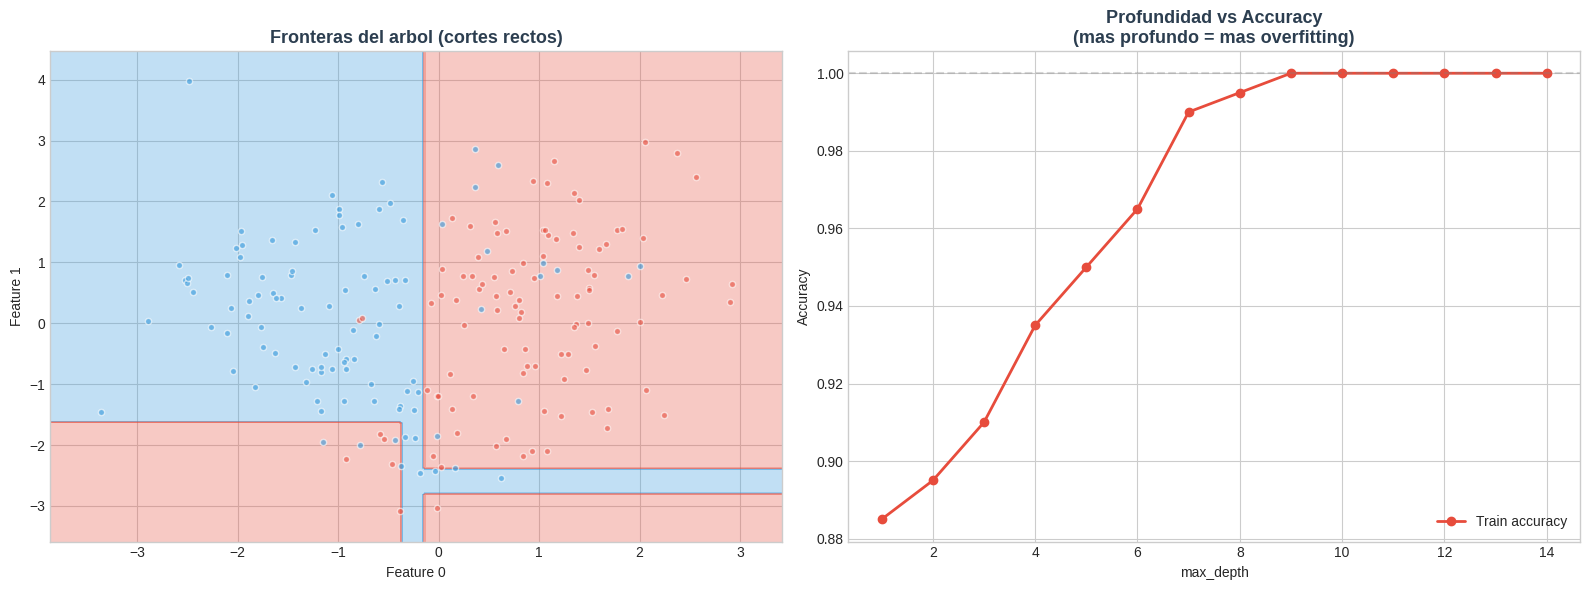

Un arbol hace prediccion bajando por las ramas: O(profundidad) = O(log n)
Random Forest = 100 arboles en paralelo. XGBoost = arboles secuenciales que corrigen errores.


In [5]:
# === Arbol de decision: como funciona internamente ===
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.datasets import make_classification
from matplotlib.colors import ListedColormap

np.random.seed(42)
X_tree, y_tree = make_classification(n_samples=200, n_features=2, n_informative=2,
                                       n_redundant=0, random_state=42)

tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_tree, y_tree)

print("Arbol de decision (max_depth=3):")
print(export_text(tree, feature_names=['Feature_0', 'Feature_1'], decimals=2))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
x_min, x_max = X_tree[:, 0].min() - 0.5, X_tree[:, 0].max() + 0.5
y_min, y_max = X_tree[:, 1].min() - 0.5, X_tree[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = tree.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap([C_PRIMARY, C_DANGER]))
ax.scatter(X_tree[y_tree==0, 0], X_tree[y_tree==0, 1], c=C_PRIMARY, s=20, alpha=0.6, edgecolors='white')
ax.scatter(X_tree[y_tree==1, 0], X_tree[y_tree==1, 1], c=C_DANGER, s=20, alpha=0.6, edgecolors='white')
ax.set_title('Fronteras del arbol (cortes rectos)', fontsize=13, fontweight='bold', color=C_DARK)
ax.set_xlabel('Feature 0')
ax.set_ylabel('Feature 1')

ax = axes[1]
depths = range(1, 15)
train_acc = []
for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_tree, y_tree)
    train_acc.append(t.score(X_tree, y_tree))

ax.plot(list(depths), train_acc, 'o-', color=C_DANGER, linewidth=2, label='Train accuracy')
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.3)
ax.set_title('Profundidad vs Accuracy\n(mas profundo = mas overfitting)', fontsize=13, fontweight='bold', color=C_DARK)
ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy')
ax.legend()

plt.tight_layout()
plt.show()

print("Un arbol hace prediccion bajando por las ramas: O(profundidad) = O(log n)")
print("Random Forest = 100 arboles en paralelo. XGBoost = arboles secuenciales que corrigen errores.")

## 6. Busqueda y Ordenamiento

| Algoritmo | Complejidad | Donde aparece en ML |
|---|---|---|
| Busqueda lineal | O(n) | `np.where()`, filtrar datos |
| Busqueda binaria | O(log n) | Encontrar umbral optimo, `np.searchsorted()` |
| Sorting | O(n log n) | Rankings, percentiles, metodo del codo |
| Heap / Priority Queue | O(log n) insert | Top-K features, KNN eficiente |

In [6]:
# === Busqueda lineal vs binaria ===
sorted_arr = np.sort(np.random.randn(1000000))
target = sorted_arr[500000]

t0 = time.perf_counter()
idx_lin = np.where(sorted_arr == target)[0][0]
t_lin = time.perf_counter() - t0

t0 = time.perf_counter()
idx_bin = np.searchsorted(sorted_arr, target)
t_bin = time.perf_counter() - t0

print(f"Buscar en 1,000,000 elementos ordenados:")
print(f"  Lineal (np.where):      {t_lin*1000:.3f} ms  ->  O(n) = 1,000,000 comparaciones")
print(f"  Binaria (searchsorted):  {t_bin*1000:.3f} ms  ->  O(log n) = 20 comparaciones")
print(f"  Speedup: {t_lin/t_bin:.0f}x")

print()

from sklearn.metrics import f1_score

np.random.seed(42)
y_true = np.random.randint(0, 2, 1000)
y_prob = np.random.beta(2, 5, 1000)

thresholds = np.linspace(0.01, 0.99, 100)
f1_scores = [f1_score(y_true, (y_prob >= t).astype(int), zero_division=0) for t in thresholds]
best_idx = np.argmax(f1_scores)

print(f"Busqueda de umbral optimo (barrido): {len(thresholds)} evaluaciones")
print(f"  Mejor umbral: {thresholds[best_idx]:.3f} (F1={f1_scores[best_idx]:.3f})")
print(f"  Esto es O(k*n) donde k=umbrales, n=muestras")

Buscar en 1,000,000 elementos ordenados:
  Lineal (np.where):      0.428 ms  ->  O(n) = 1,000,000 comparaciones
  Binaria (searchsorted):  0.045 ms  ->  O(log n) = 20 comparaciones
  Speedup: 9x

Busqueda de umbral optimo (barrido): 100 evaluaciones
  Mejor umbral: 0.010 (F1=0.675)
  Esto es O(k*n) donde k=umbrales, n=muestras


## 7. Complejidad de Algoritmos de ML

| Algoritmo | Entrenamiento | Prediccion | Memoria |
|---|---|---|---|
| Linear Regression (OLS) | O(np² + p³) | O(p) | O(p) |
| Linear Regression (SGD) | O(npe) | O(p) | O(p) |
| Decision Tree | O(np log n) | O(log n) | O(nodos) |
| Random Forest | O(T·np log n) | O(T·log n) | O(T·nodos) |
| XGBoost | O(T·np log n) | O(T·log n) | O(T·nodos) |
| KNN | O(1) (lazy) | O(np) | O(np) |
| SVM | O(n²p) a O(n³p) | O(sv·p) | O(sv·p) |
| LSTM | O(e·n·s·h²) | O(s·h²) | O(h²) |

Donde: n=muestras, p=features, T=arboles, e=epochs, s=seq_length, h=hidden_size, sv=support vectors

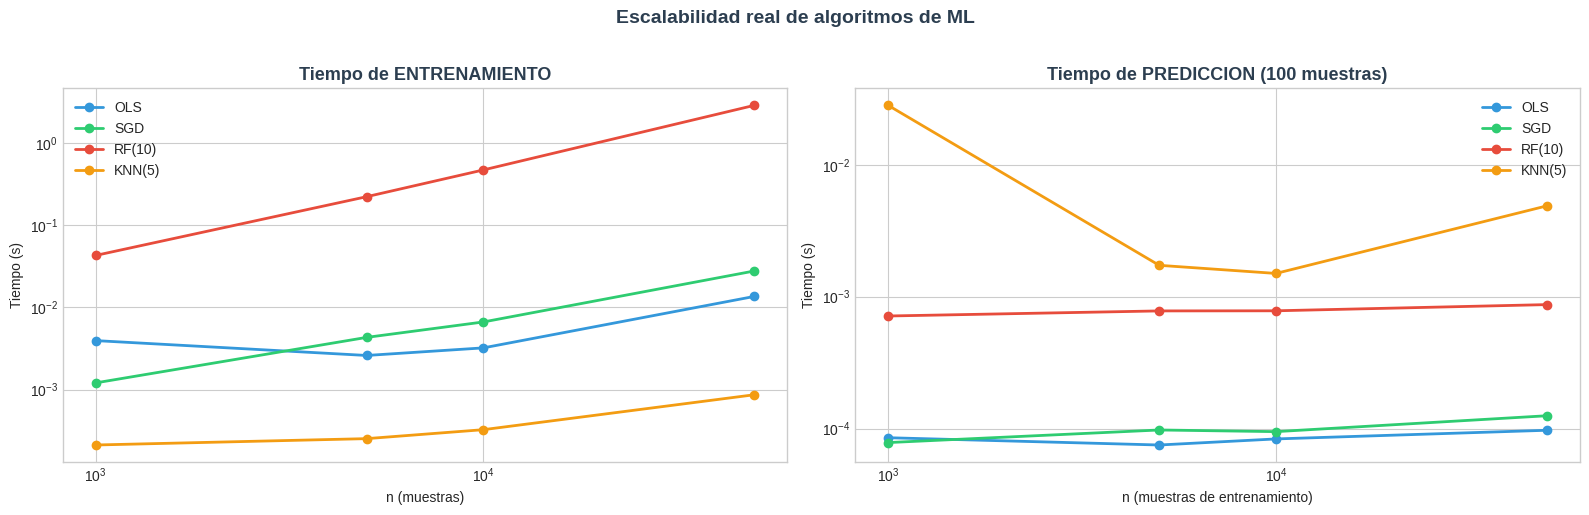

OLS: rapido pero O(p^3) con muchas features
SGD: escala linealmente con n (ideal para big data)
RF: rapido para predecir, moderado para entrenar
KNN: no entrena (lazy), pero prediccion es O(n) — lento con muchos datos


In [7]:
# === Medir tiempo real de entrenamiento de algoritmos ===
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

np.random.seed(42)
sizes = [1000, 5000, 10000, 50000]
n_features = 20

results_train = {name: [] for name in ['OLS', 'SGD', 'RF(10)', 'KNN(5)']}
results_pred = {name: [] for name in ['OLS', 'SGD', 'RF(10)', 'KNN(5)']}

for n in sizes:
    X = np.random.randn(n, n_features)
    y = np.random.randn(n)
    X_test = np.random.randn(100, n_features)
    
    models = {
        'OLS': LinearRegression(),
        'SGD': SGDRegressor(max_iter=100, random_state=42),
        'RF(10)': RandomForestRegressor(n_estimators=10, max_depth=5, random_state=42),
        'KNN(5)': KNeighborsRegressor(n_neighbors=5),
    }
    
    for name, model in models.items():
        t0 = time.perf_counter()
        model.fit(X, y)
        results_train[name].append(time.perf_counter() - t0)
        
        t0 = time.perf_counter()
        model.predict(X_test)
        results_pred[name].append(time.perf_counter() - t0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = [C_PRIMARY, C_SUCCESS, C_DANGER, C_ORANGE]

ax = axes[0]
for (name, times), color in zip(results_train.items(), colors):
    ax.plot(sizes, times, 'o-', linewidth=2, color=color, label=name)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Tiempo de ENTRENAMIENTO', fontsize=13, fontweight='bold', color=C_DARK)
ax.set_xlabel('n (muestras)')
ax.set_ylabel('Tiempo (s)')
ax.legend()

ax = axes[1]
for (name, times), color in zip(results_pred.items(), colors):
    ax.plot(sizes, times, 'o-', linewidth=2, color=color, label=name)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Tiempo de PREDICCION (100 muestras)', fontsize=13, fontweight='bold', color=C_DARK)
ax.set_xlabel('n (muestras de entrenamiento)')
ax.set_ylabel('Tiempo (s)')
ax.legend()

plt.suptitle('Escalabilidad real de algoritmos de ML', fontsize=14, fontweight='bold', color=C_DARK, y=1.02)
plt.tight_layout()
plt.show()

print("OLS: rapido pero O(p^3) con muchas features")
print("SGD: escala linealmente con n (ideal para big data)")
print("RF: rapido para predecir, moderado para entrenar")
print("KNN: no entrena (lazy), pero prediccion es O(n) — lento con muchos datos")

## 8. Resumen: Lo que Necesitas Saber

### Reglas de oro para ML/Data Science

1. **Vectoriza todo:** Nunca uses loops de Python para operaciones numericas. Usa numpy/pandas.
2. **Conoce la complejidad de tu modelo:** Si tu dataset tiene 1M filas, SVM y KNN seran lentos.
3. **DataFrames:** Usa `.groupby()`, `.query()`, `np.where()`. Evita `.iterrows()` y `.apply(lambda)`.
4. **Producto matricial es la operacion core:** `X @ W` es lo que hacen regresion, redes neuronales y LSTM.
5. **GPU = matrices en paralelo:** Por eso deep learning necesita GPU — miles de multiplicaciones simultaneas.

### Lo que NO necesitas

- Implementar quicksort desde cero
- Grafos complejos (a menos que hagas GNNs)
- Programacion dinamica avanzada
- Arboles AVL, red-black trees

Lo importante es **saber elegir** la herramienta correcta segun el tamanio y tipo de tus datos.